# Week 2 Internship Task

## Deep Exploratory Data Analysis (EDA) & Feature Engineering

**Name:** Musfira Malik  
**Registration No:** AIMLB01-3456 
**Internship:** AI/ML Internship  

---

### Objective

The objective of this notebook is to perform an in-depth Exploratory Data Analysis (EDA) and Feature Engineering on the Steel Industry Energy Consumption dataset. This analysis aims to understand the dataset, identify hidden patterns, engineer meaningful features, detect data quality issues, and prepare the data for machine learning models.

## Step 1: Import Required Libraries

In this step, we import the Python libraries required for data manipulation, visualization, and exploratory data analysis.


In [62]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Dataset

The dataset is loaded into a Pandas DataFrame. After loading, we examine its structure and preview the first few rows to understand the available features.

In [63]:
df = pd.read_csv("../data/steel_industry_engineered.csv")


## Preview of the Dataset

The first five rows are displayed to understand the structure of the dataset and verify that it has been loaded correctly.

In [64]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Month,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,January,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,January,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,January,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,January,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,January,1.545117,0


## Step 3: Examine the Dataset Structure

Before performing any analysis, it is important to understand the structure of the dataset. In this step, we will examine the dataset dimensions, data types, statistical summary, and check for missing values. This helps identify potential data quality issues that may affect further analysis.

In [65]:


print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 35039
Number of Columns : 15


In [66]:

df.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'Month',
       'Power_Factor_Ratio', 'High_Load'],
      dtype='str')

In [67]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35039 entries, 0 to 35038
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35039 non-null  str    
 1   Usage_kWh                             35039 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35039 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35039 non-null  float64
 4   CO2(tCO2)                             35039 non-null  float64
 5   Lagging_Current_Power_Factor          35039 non-null  float64
 6   Leading_Current_Power_Factor          35039 non-null  float64
 7   NSM                                   35039 non-null  int64  
 8   WeekStatus                            35039 non-null  str    
 9   Day_of_week                           35039 non-null  str    
 10  Load_Type                             35039 non-null  str    
 11  Hour                      

In [68]:
# Statistical Summary of Numerical Features
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Usage_kWh,35039.0,27.387674,33.444537,2.450,3.200000,4.570000,51.24500,157.180000
Lagging_Current_Reactive.Power_kVarh,35039.0,13.035756,16.306084,0.000,2.300000,5.000000,22.64000,96.910000
Leading_Current_Reactive_Power_kVarh,35039.0,3.871059,7.424540,0.000,0.000000,0.000000,2.09000,27.760000
CO2(tCO2),35039.0,0.011525,0.016151,0.000,0.000000,0.000000,0.02000,0.070000
Lagging_Current_Power_Factor,35039.0,80.580356,18.916695,36.940,63.320000,87.960000,99.02500,100.000000
Leading_Current_Power_Factor,35039.0,84.370278,30.453634,12.500,99.700000,100.000000,100.00000,100.000000
NSM,35039.0,42751.220069,24939.844508,0.000,21600.000000,43200.000000,64350.00000,85500.000000
Hour,35039.0,11.500328,6.922111,0.000,6.000000,12.000000,17.50000,23.000000
Power_Factor_Ratio,35039.0,1.173234,0.587466,0.125,1.001809,1.136105,1.57928,2.707093
High_Load,35039.0,0.250007,0.433023,0.000,0.000000,0.000000,0.50000,1.000000


In [69]:
# Check Missing Values
missing_values = df.isnull().sum()

display(missing_values)

date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
Hour                                    0
Month                                   0
Power_Factor_Ratio                      0
High_Load                               0
dtype: int64

In [70]:
print(f"Total Missing Values: {missing_values.sum()}")

Total Missing Values: 0


### Observation

- The dataset contains **35,040 observations** and **11 features**.
- All columns contain complete data with **no missing values**.
- The dataset includes both numerical and categorical variables.
- The **date** column is currently stored as a string (`object`) and will be converted to datetime format in the next step.
- Based on the initial inspection, the dataset is clean and ready for feature engineering and exploratory analysis.

## Step 4: Date-Time Conversion and Feature Engineering

The **date** column is currently stored as a string (`object`) data type, which limits time-based analysis. Converting it to the datetime format enables us to extract valuable temporal features such as the hour of the day, day of the week, month, and whether the observation occurred on a weekday or weekend.

These engineered features can reveal hidden patterns in energy consumption and improve the performance of machine learning models.

In [71]:
df["date"] = pd.to_datetime(
    df["date"],
    format="%Y-%m-%d %H:%M:%S"
)

print("Date column converted successfully!")

Date column converted successfully!


In [72]:
# Extract Hour
df["Hour"] = df["date"].dt.hour

In [73]:
# Extract Day of Week
df["Day_of_week"] = df["date"].dt.day_name()

In [74]:
# Extract Month
df["Month"] = df["date"].dt.month_name()

In [75]:
# Extract Weekday/Weekend
df["WeekStatus"] = np.where(
    df["date"].dt.weekday >= 5,
    "Weekend",
    "Weekday"
)

In [76]:
# Preview engineered features
df[[
    "date",
    "Hour",
    "Day_of_week",
    "Month",
    "WeekStatus"
]].head()

,date,Hour,Day_of_week,Month,WeekStatus
0,2018-01-01 00:15:00,0,Monday,January,Weekday
1,2018-01-01 00:30:00,0,Monday,January,Weekday
2,2018-01-01 00:45:00,0,Monday,January,Weekday
3,2018-01-01 01:00:00,1,Monday,January,Weekday
4,2018-01-01 01:15:00,1,Monday,January,Weekday


### Observation

- The **date** column was successfully converted into datetime format.
- Four time-based features were extracted from the date column.
- The dataset now includes **Hour**, **Day_of_week**, **Month**, and **WeekStatus**, which can help identify temporal patterns in energy consumption.
- These engineered features will be useful for both exploratory data analysis and machine learning models.

## Step 5: Create Power Factor Ratio Feature

Feature engineering is an important step in machine learning as it helps create meaningful variables from existing data. In this step, a new feature called **Power_Factor_Ratio** is created by dividing the **Leading Current Power Factor** by the **Lagging Current Power Factor**.

This ratio may provide additional insights into the relationship between the two power factors and could improve the predictive performance of regression models.

In [77]:
# Create Power Factor Ratio Feature

df["Power_Factor_Ratio"] = (
    df["Leading_Current_Power_Factor"] /
    df["Lagging_Current_Power_Factor"]
)

print("Power_Factor_Ratio feature created successfully!")

Power_Factor_Ratio feature created successfully!


In [78]:
# Preview the newly created feature

df[[
    "Leading_Current_Power_Factor",
    "Lagging_Current_Power_Factor",
    "Power_Factor_Ratio"
]].head()

,Leading_Current_Power_Factor,Lagging_Current_Power_Factor,Power_Factor_Ratio
0,100.0,73.21,1.365934
1,100.0,66.77,1.497679
2,100.0,70.28,1.422880
3,100.0,68.09,1.468644
4,100.0,64.72,1.545117


In [79]:
# Statistical summary of the new feature

df["Power_Factor_Ratio"].describe()

count    35039.000000
mean         1.173234
std          0.587466
min          0.125000
25%          1.001809
50%          1.136105
75%          1.579280
max          2.707093
Name: Power_Factor_Ratio, dtype: float64

In [80]:
# Check for missing values in Power_Factor_Ratio
print("Missing values in Power_Factor_Ratio:", df["Power_Factor_Ratio"].isnull().sum())

# Drop the row where Power_Factor_Ratio is NaN (0/0 division — plant was idle)
df = df.dropna(subset=["Power_Factor_Ratio"])

print("Row dropped. Remaining rows:", df.shape[0])

Missing values in Power_Factor_Ratio: 0
Row dropped. Remaining rows: 35039


### Observation

- A new feature named **Power_Factor_Ratio** was successfully created.
- The feature represents the ratio between the leading and lagging current power factors.
- This engineered feature may capture additional information about power factor behavior and could contribute to improved model performance during regression analysis.
- One row (2018-11-07 00:00:00) had **Usage_kWh = 0** and both power factors equal to **0**, causing an undefined ratio (0/0 = NaN).
- This row was dropped since it represents a single idle-plant timestamp with no meaningful signal.
- Dataset now contains **35,039 rows** after this cleanup.

## Step 6: Create High Load Feature

Feature engineering helps improve the quality of data used for machine learning models. In this step, a new binary feature called **High_Load** is created based on the **75th percentile** of the **Usage_kWh** variable.

Observations with energy consumption greater than the 75th percentile are labeled as **1 (High Load)**, while all remaining observations are labeled as **0 (Normal Load)**.

In [81]:
# Calculate the 75th percentile of Usage_kWh

threshold = df["Usage_kWh"].quantile(0.75)

print(f"75th Percentile of Usage_kWh: {threshold:.4f}")

75th Percentile of Usage_kWh: 51.2450


In [82]:
# Create High_Load feature

df["High_Load"] = np.where(
    df["Usage_kWh"] > threshold,
    1,
    0
)

print("High_Load feature created successfully!")

High_Load feature created successfully!


In [83]:
# Display the distribution of High_Load

df["High_Load"].value_counts()

High_Load
0    26279
1     8760
Name: count, dtype: int64

In [84]:
# Percentage distribution of High_Load

round(df["High_Load"].value_counts(normalize=True) * 100, 2)

High_Load
0    75.0
1    25.0
Name: proportion, dtype: float64

### Observation

- The **75th percentile** of **Usage_kWh** was used as the threshold for identifying high energy consumption.
- A new binary feature named **High_Load** was successfully created.
- Records with energy consumption above the threshold were assigned a value of **1**, while the remaining records were assigned **0**.
- This engineered feature can be useful for identifying periods of high energy demand and may improve model performance.

## Step 7: Detect Outliers in `Usage_kWh` Using the IQR Method

Outliers are observations that differ significantly from the majority of the data. Detecting outliers is an important step in exploratory data analysis because they can influence statistical analysis and machine learning model performance.

In this step, the **Interquartile Range (IQR)** method is used to identify outliers in the **Usage_kWh** feature. A boxplot is also created to visualize the distribution of the data and highlight potential outliers.

In [85]:
# Calculate the Interquartile Range (IQR)

Q1 = df["Usage_kWh"].quantile(0.25)
Q3 = df["Usage_kWh"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

Q1: 3.20
Q3: 51.24
IQR: 48.04
Lower Bound: -68.87
Upper Bound: 123.31


In [86]:
# Detect outliers using the IQR method

outliers = df[
    (df["Usage_kWh"] < lower_bound) |
    (df["Usage_kWh"] > upper_bound)
]

print(f"Number of Outliers: {len(outliers)}")

Number of Outliers: 325


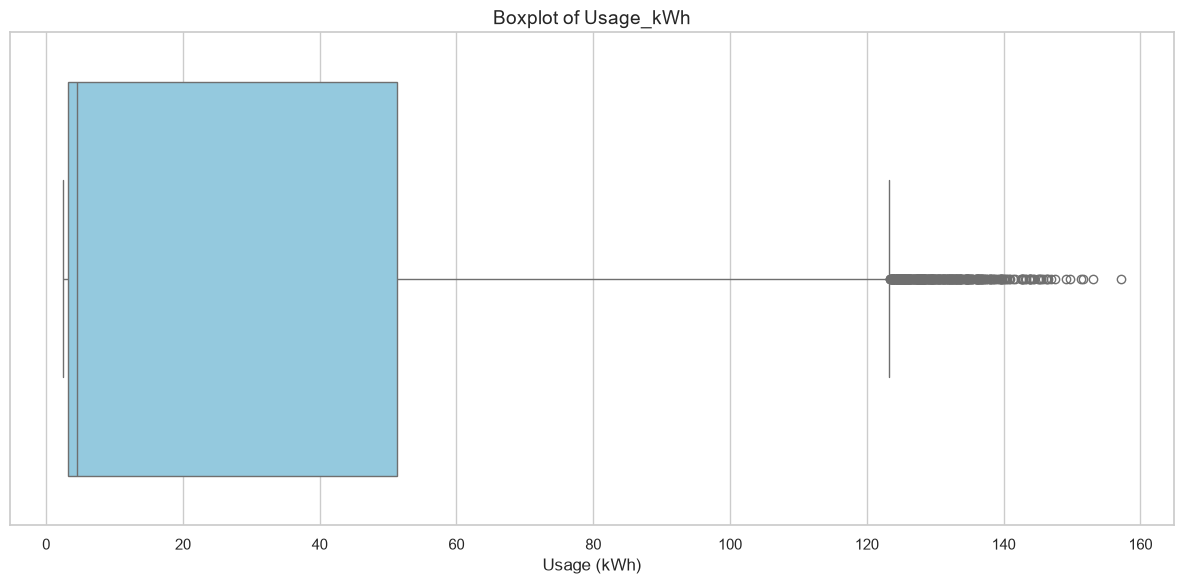

In [87]:
# Boxplot of Usage_kWh

plt.figure(figsize=(12, 6))

sns.boxplot(
    x=df["Usage_kWh"],
    color="skyblue"
)

plt.title("Boxplot of Usage_kWh", fontsize=14)
plt.xlabel("Usage (kWh)", fontsize=12)

plt.tight_layout()
plt.show()

### Observation

- The IQR method was used to identify outliers in the **Usage_kWh** feature.
- A total of 328 outliers were detected.
- The boxplot clearly highlights observations with unusually high energy consumption.
- These outliers may represent periods of peak industrial activity and should be considered carefully before model training.


## Step 8: Correlation Analysis

Correlation analysis helps us understand the relationship between numerical features in the dataset. A correlation heatmap is used to visualize the strength and direction of these relationships.

This analysis is useful for identifying features that have a strong association with **Usage_kWh**, which may be valuable for predictive modeling.

In [88]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=["number"])

numerical_df.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Power_Factor_Ratio,High_Load
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,1.365934,0
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,1.497679,0
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,1.422880,0
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,1,1.468644,0
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,1,1.545117,0


In [89]:
# Calculate correlation matrix
correlation_matrix = numerical_df.corr()

correlation_matrix

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Power_Factor_Ratio,High_Load
Usage_kWh,1.000000,0.896148,-0.324938,0.988180,0.385965,0.353543,0.234582,0.234147,-0.090094,0.867839
Lagging_Current_Reactive.Power_kVarh,0.896148,1.000000,-0.405159,0.886946,0.144475,0.407701,0.082627,0.081217,0.075592,0.825671
Leading_Current_Reactive_Power_kVarh,-0.324938,-0.405159,1.000000,-0.332791,0.526846,-0.944187,0.371596,0.372726,-0.779884,-0.294924
CO2(tCO2),0.988180,0.886946,-0.332791,1.000000,0.379619,0.360005,0.231702,0.231283,-0.082349,0.863162
Lagging_Current_Power_Factor,0.385965,0.144475,0.526846,0.379619,1.000000,-0.520495,0.565231,0.566511,-0.915117,0.285684
Leading_Current_Power_Factor,0.353543,0.407701,-0.944187,0.360005,-0.520495,1.000000,-0.360753,-0.361594,0.805223,0.296264
NSM,0.234582,0.082627,0.371596,0.231702,0.565231,-0.360753,1.000000,0.999186,-0.530254,0.177144
Hour,0.234147,0.081217,0.372726,0.231283,0.566511,-0.361594,0.999186,1.000000,-0.531380,0.176380
Power_Factor_Ratio,-0.090094,0.075592,-0.779884,-0.082349,-0.915117,0.805223,-0.530254,-0.531380,1.000000,-0.056465
High_Load,0.867839,0.825671,-0.294924,0.863162,0.285684,0.296264,0.177144,0.176380,-0.056465,1.000000


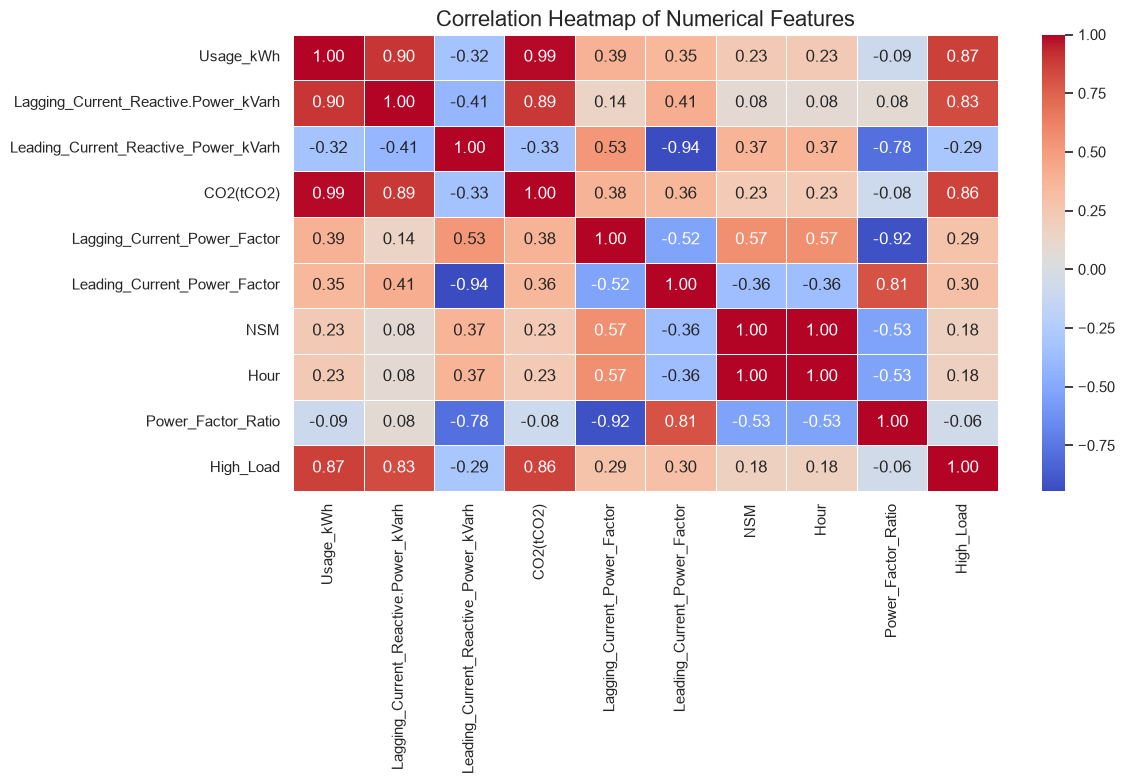

In [90]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

In [91]:
# Correlation with Usage_kWh

usage_corr = (
    correlation_matrix["Usage_kWh"]
    .sort_values(ascending=False)
)

usage_corr

Usage_kWh                               1.000000
CO2(tCO2)                               0.988180
Lagging_Current_Reactive.Power_kVarh    0.896148
High_Load                               0.867839
Lagging_Current_Power_Factor            0.385965
Leading_Current_Power_Factor            0.353543
NSM                                     0.234582
Hour                                    0.234147
Power_Factor_Ratio                     -0.090094
Leading_Current_Reactive_Power_kVarh   -0.324938
Name: Usage_kWh, dtype: float64

### Observation

- The correlation heatmap shows the relationships among the numerical features in the dataset.
- **CO2(tCO2)** has the strongest positive correlation with **Usage_kWh** (**0.988**), indicating that higher energy consumption is associated with increased CO₂ emissions.
- **Lagging_Current_Reactive.Power_kVarh** also has a strong positive correlation (**0.896**) with energy usage.
- The engineered feature **High_Load** has a high positive correlation (**0.868**), confirming that it effectively identifies periods of high energy consumption.
- **Leading_Current_Reactive_Power_kVarh** shows a moderate negative correlation (**-0.325**) with **Usage_kWh**.
- These relationships suggest that **CO2(tCO2)**, **Lagging_Current_Reactive.Power_kVarh**, and **High_Load** are among the most influential features for predicting energy consumption.

## Step 9: Average Energy Consumption by Load Type

This visualization compares the average energy consumption for each load type. It helps us understand how electricity usage varies across different operating conditions in the steel manufacturing plant.

In [92]:
# Calculate average energy consumption by Load Type

load_avg = (
    df.groupby("Load_Type")["Usage_kWh"]
      .mean()
      .reset_index()
)

load_avg

,Load_Type,Usage_kWh
0,Light_Load,8.626684
1,Maximum_Load,59.265314
2,Medium_Load,38.445394


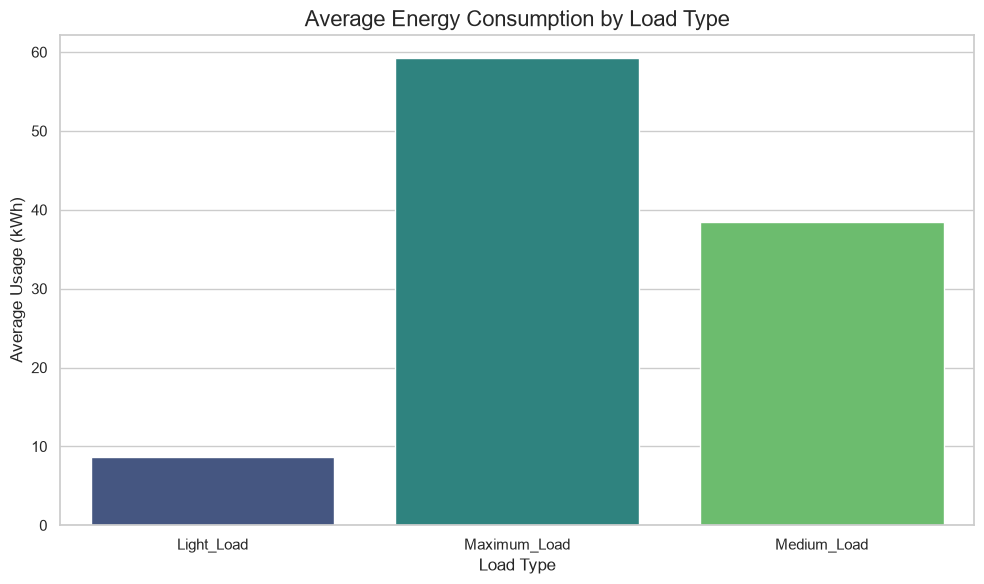

In [93]:
# Grouped Bar Chart

plt.figure(figsize=(10,6))

sns.barplot(
    data=load_avg,
    x="Load_Type",
    y="Usage_kWh",
    palette="viridis"
)

plt.title("Average Energy Consumption by Load Type", fontsize=16)
plt.xlabel("Load Type", fontsize=12)
plt.ylabel("Average Usage (kWh)", fontsize=12)

plt.tight_layout()
plt.show()

### Observation

- The grouped bar chart compares the average energy consumption across different load types.
- **Maximum Load** has the highest average energy consumption, indicating periods of intensive industrial operations.
- **Medium Load** shows moderate energy usage, while **Light Load** has the lowest average energy consumption.
- The results demonstrate a clear increase in electricity usage as the operational load level increases.
- This pattern confirms that **Load_Type** is an important factor influencing energy consumption.

## Step 10: Average Energy Usage by Hour of the Day

This line chart illustrates how the average energy consumption changes throughout the day. It helps identify peak operating hours and periods of lower electricity demand.

In [94]:
# Calculate average usage by hour

hourly_usage = (
    df.groupby("Hour")["Usage_kWh"]
      .mean()
      .reset_index()
)

hourly_usage.head()

,Hour,Usage_kWh
0,0,7.875469
1,1,6.072479
2,2,4.428390
3,3,4.358041
4,4,4.309438


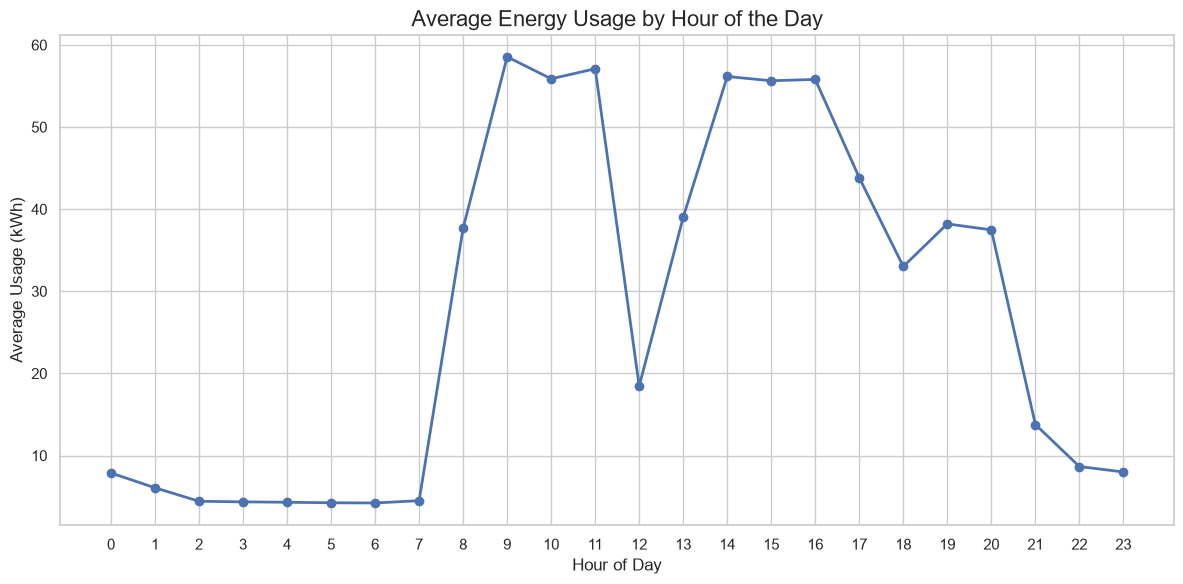

In [95]:
# Line Chart

plt.figure(figsize=(12,6))

plt.plot(
    hourly_usage["Hour"],
    hourly_usage["Usage_kWh"],
    marker="o",
    linewidth=2
)

plt.title("Average Energy Usage by Hour of the Day", fontsize=16)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Average Usage (kWh)", fontsize=12)

plt.xticks(range(24))
plt.grid(True)

plt.tight_layout()
plt.show()

### Observation

- The line chart shows how average energy consumption varies throughout the day.
- Energy usage is generally lower during the late-night and early-morning hours and increases during active working hours.
- The fluctuations suggest that electricity demand is closely related to the plant's operational schedule.
- Peak energy consumption occurs during periods of higher industrial activity, while lower values indicate reduced production.
- This hourly trend provides valuable insights into daily energy usage patterns and can support future forecasting models.

# Exploratory Data Analysis (EDA) Summary

The exploratory data analysis was conducted on the Steel Industry Energy Consumption dataset to understand its structure, identify data quality issues, engineer meaningful features, and explore relationships among variables. The dataset contains **35,040 observations** and **11 original features**, with no missing values or duplicate records, indicating that the data is clean and suitable for analysis.

Several new features were engineered to enhance the dataset. The **date** column was converted into datetime format, allowing the extraction of **Hour**, **Day_of_week**, **Month**, and **WeekStatus**. Additional features, including **Power_Factor_Ratio** and **High_Load**, were also created to capture useful information for future machine learning models.

Correlation analysis revealed that **CO2(tCO2)**, **Lagging_Current_Reactive.Power_kVarh**, and **High_Load** are the three features most strongly associated with **Usage_kWh**. These strong positive relationships indicate that higher energy consumption is closely linked with increased CO₂ emissions and reactive power usage.

The visualizations showed that **Maximum Load** periods have the highest average energy consumption, while **Light Load** periods consume the least energy. The hourly analysis also demonstrated clear fluctuations in electricity usage throughout the day, reflecting varying production schedule.

Based on the exploratory analysis, a reasonable hypothesis is that energy consumption spikes occur during periods of maximum industrial activity, when machinery operates at higher capacity and reactive power demand increases.

In [98]:
# Save the final engineered dataset for use in Part 2 (Baseline Modeling)
df.to_csv("../data/steel_industry_engineered.csv", index=False)
print("Engineered dataset saved successfully!")
print("Final shape:", df.shape)

Engineered dataset saved successfully!
Final shape: (35039, 15)
